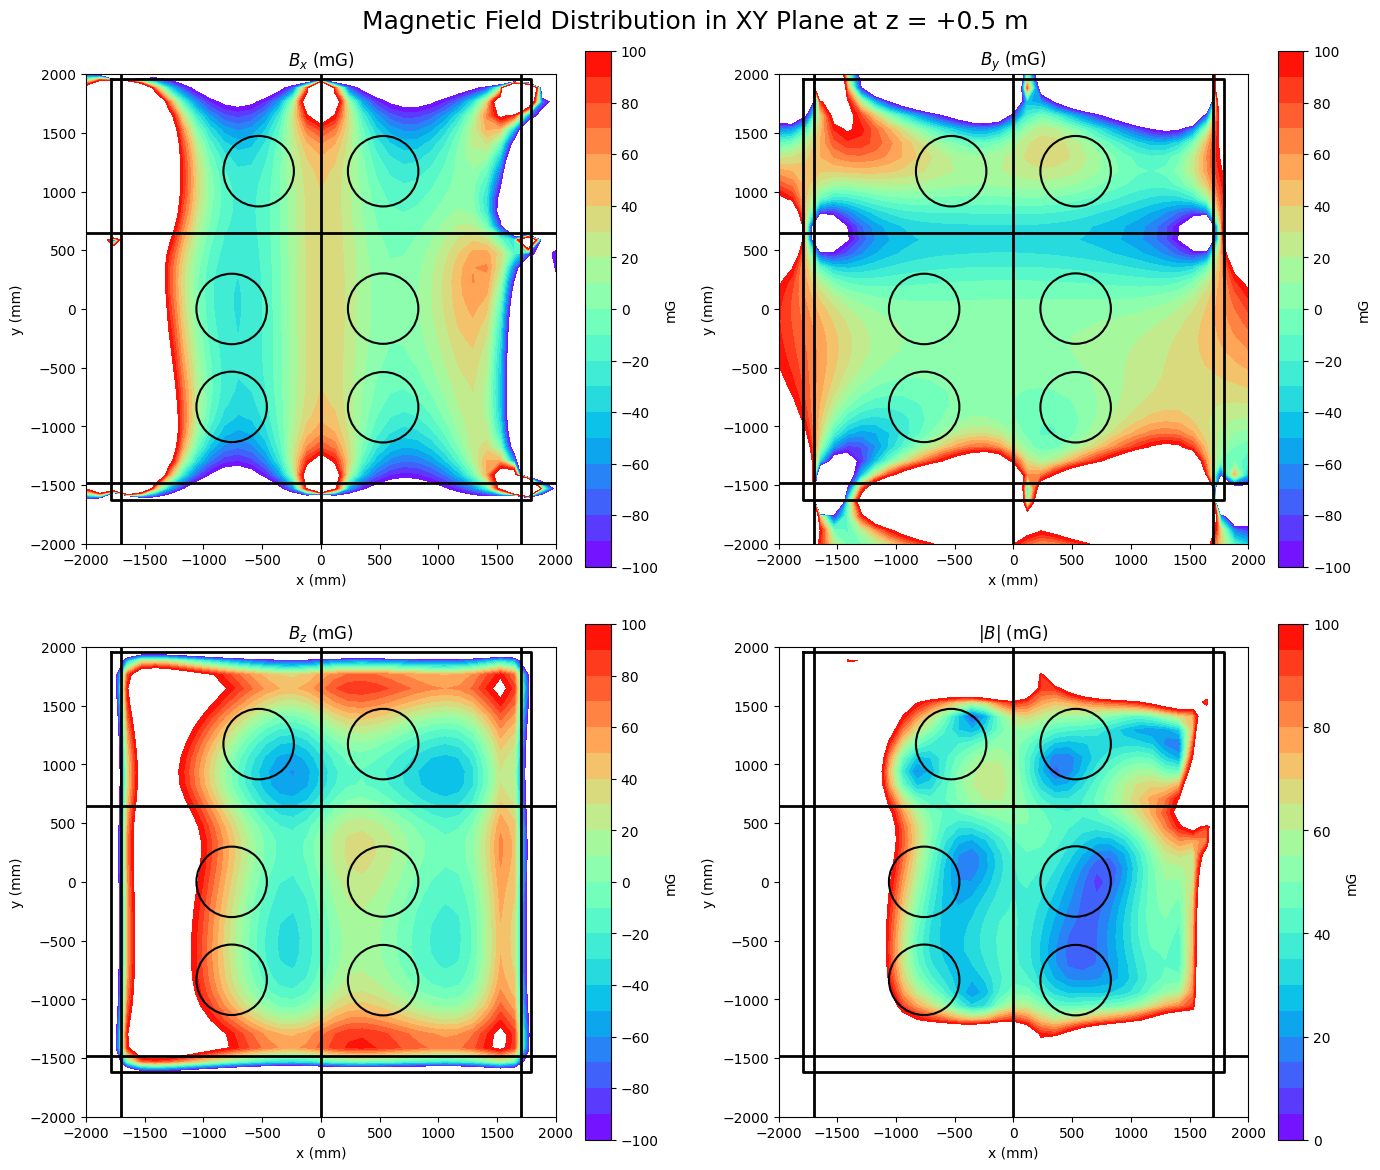

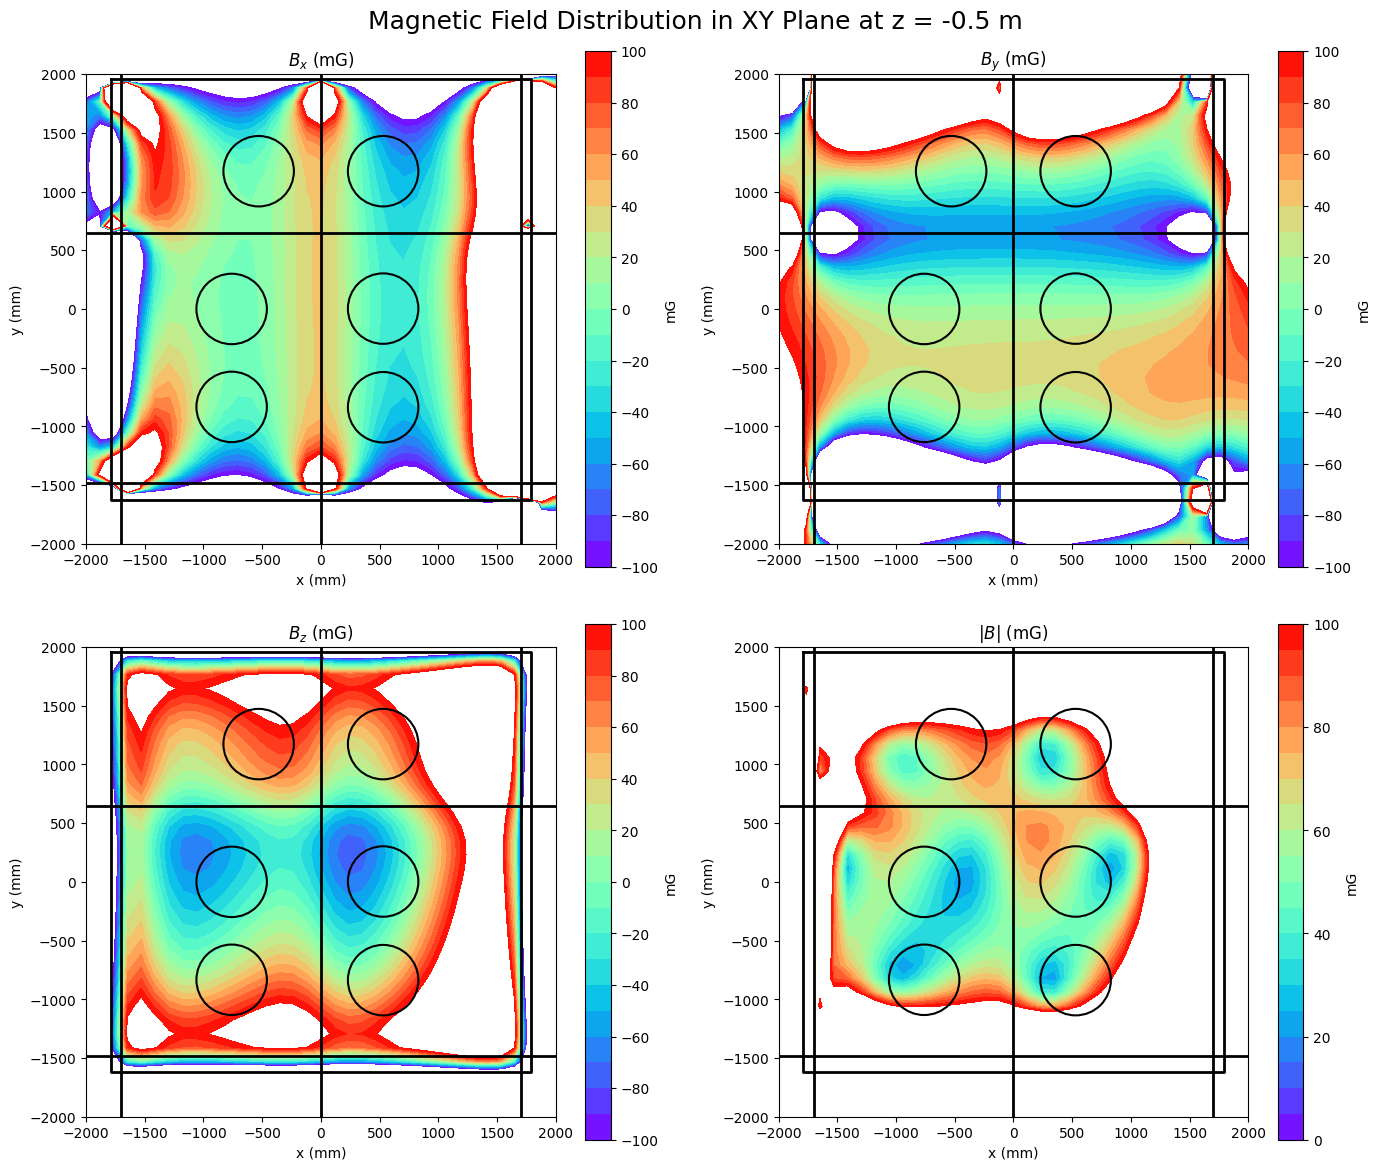

In [1]:
# ============================================================
# LOAD FIELD MAPS
# BUILD TOTAL FIELD INCLUDING AMBIENT FIELD
# PLOT FIGURE-15 STYLE MAPS
# FOR z = +0.5 m AND z = -0.5 m
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# LOAD DATA
# ============================================================

project_root = Path.cwd().parent
data_dir = project_root / "data"

# ------------------------------------------------------------
# +0.5 m maps
# ------------------------------------------------------------

data_p = np.load(
    data_dir / "field_maps_zp05.npz",
    allow_pickle=True
)

field_maps_p = data_p['field_maps'].item()

X = data_p['X']
Y = data_p['Y']

# ------------------------------------------------------------
# -0.5 m maps
# ------------------------------------------------------------

data_m = np.load(
    data_dir / "field_maps_zm05.npz",
    allow_pickle=True
)

field_maps_m = data_m['field_maps'].item()

# ============================================================
# CURRENTS (TABLE 6)
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

Bx_ambient = -283.38
By_ambient =  106.79
Bz_ambient = -381.21

# ============================================================
# BUILD TOTAL FIELD MAPS
# ============================================================

def build_total_maps(field_maps, currents):

    # --------------------------------------------------------
    # COIL FIELD
    # --------------------------------------------------------

    Bx_total = np.zeros_like(X)
    By_total = np.zeros_like(X)
    Bz_total = np.zeros_like(X)

    for coil_name, I in currents.items():

        Bx_total += I * field_maps[coil_name]['Bx']
        By_total += I * field_maps[coil_name]['By']
        Bz_total += I * field_maps[coil_name]['Bz']

    # --------------------------------------------------------
    # ADD AMBIENT FIELD
    # --------------------------------------------------------

    Bx_total += Bx_ambient
    By_total += By_ambient
    Bz_total += Bz_ambient

    # --------------------------------------------------------
    # MAGNITUDE
    # --------------------------------------------------------

    Bmag_total = np.sqrt(

        Bx_total**2 +
        By_total**2 +
        Bz_total**2
    )

    return Bx_total, By_total, Bz_total, Bmag_total

# ============================================================
# BUILD TOTAL MAPS
# ============================================================

Bx_p, By_p, Bz_p, Bmag_p = build_total_maps(
    field_maps_p,
    currents
)

Bx_m, By_m, Bz_m, Bmag_m = build_total_maps(
    field_maps_m,
    currents
)

# ============================================================
# PMT POSITIONS (mm)
# ============================================================

PMTs = {

    'PMT1': (-760, -834),
    'PMT2': (-760,    0),
    'PMT3': (-530, 1173),

    'PMT4': ( 530, -837),
    'PMT5': ( 530,    3),
    'PMT6': ( 530, 1173),
}

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_maps(
    Bx_total,
    By_total,
    Bz_total,
    Bmag_total,
    z_title
):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14,12)
    )

    plots = [

        (Bx_total, r'$B_x$ (mG)', -100, 100),
        (By_total, r'$B_y$ (mG)', -100, 100),
        (Bz_total, r'$B_z$ (mG)', -100, 100),
        (Bmag_total, r'$|B|$ (mG)', 0, 100)
    ]

    for ax, (data, title, vmin, vmax) in zip(axes.flat, plots):

        # ----------------------------------------------------
        # CONTOUR MAP
        # ----------------------------------------------------

        im = ax.contourf(

            X * 1000,
            Y * 1000,

            data,

            levels=np.linspace(vmin, vmax, 21),

            cmap='rainbow',

            vmin=vmin,
            vmax=vmax
        )

        # ----------------------------------------------------
        # COLORBAR
        # ----------------------------------------------------

        cbar = plt.colorbar(
            im,
            ax=ax
        )

        cbar.set_label('mG')

        if title != r'$|B|$ (mG)':

            cbar.set_ticks(
                np.arange(-100, 101, 20)
            )

        else:

            cbar.set_ticks(
                np.arange(0, 101, 20)
            )

        # ----------------------------------------------------
        # PMT CIRCLES
        # ----------------------------------------------------

        for name, (xp, yp) in PMTs.items():

            circle = plt.Circle(

                (xp, yp),

                300,

                fill=False,
                color='black',
                linewidth=1.5
            )

            ax.add_patch(circle)

        # ----------------------------------------------------
        # X COILS
        # ----------------------------------------------------

        for xcoil in [-1700, 0, 1700]:

            ax.axvline(
                x=xcoil,
                color='black',
                linewidth=2
            )

        # ----------------------------------------------------
        # Y COILS
        # ----------------------------------------------------

        for ycoil in [648, -1482]:

            ax.axhline(
                y=ycoil,
                color='black',
                linewidth=2
            )

        # ----------------------------------------------------
        # Z COIL RECTANGLE
        # ----------------------------------------------------

        z_x0 = -1791
        z_y0 =  1959

        z_width = 3582
        z_height = 3582

        rect_x = [

            z_x0,
            z_x0 + z_width,
            z_x0 + z_width,
            z_x0,
            z_x0
        ]

        rect_y = [

            z_y0,
            z_y0,
            z_y0 - z_height,
            z_y0 - z_height,
            z_y0
        ]

        ax.plot(
            rect_x,
            rect_y,
            color='black',
            linewidth=2
        )

        # ----------------------------------------------------
        # LABELS
        # ----------------------------------------------------

        ax.set_title(title)

        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')

        ax.set_aspect('equal')

    fig.suptitle(
        z_title,
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

# ============================================================
# PLOT z = +0.5 m
# ============================================================

plot_maps(

    Bx_p,
    By_p,
    Bz_p,
    Bmag_p,

    r'Magnetic Field Distribution in XY Plane at z = +0.5 m'
)

# ============================================================
# PLOT z = -0.5 m
# ============================================================

plot_maps(

    Bx_m,
    By_m,
    Bz_m,
    Bmag_m,

    r'Magnetic Field Distribution in XY Plane at z = -0.5 m'
)

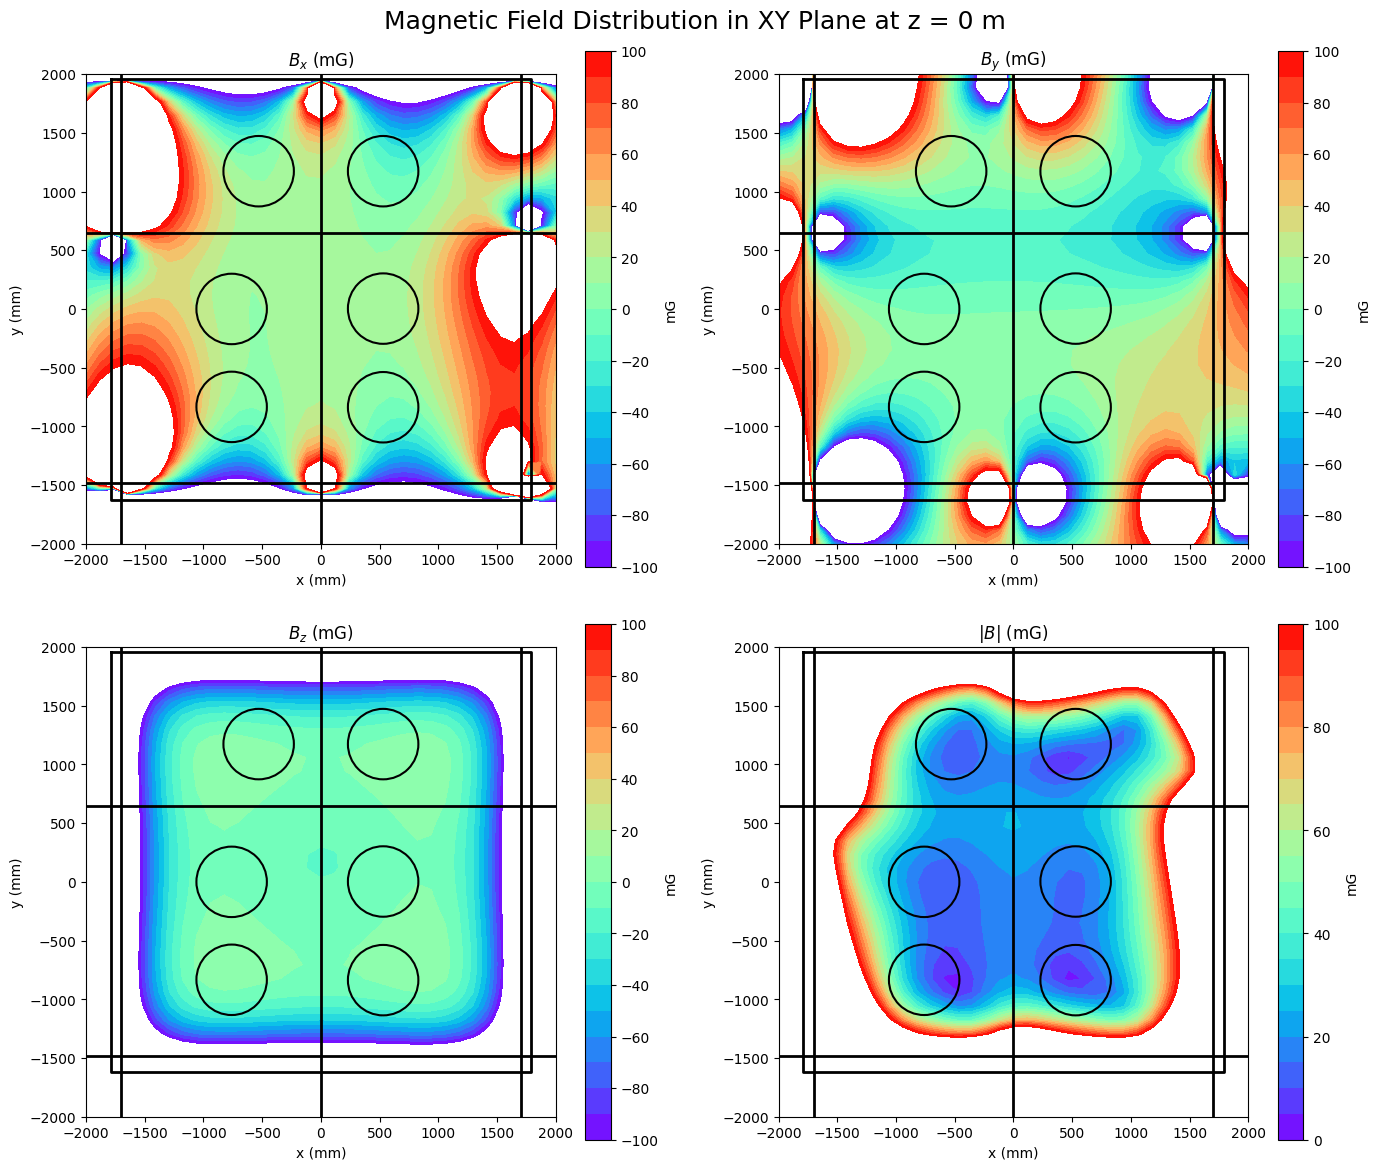

In [2]:
# ============================================================
# LOAD FIELD MAPS
# BUILD TOTAL FIELD INCLUDING AMBIENT FIELD
# PLOT FIGURE-15 STYLE MAPS
# FOR z = 0 m
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# LOAD DATA
# ============================================================

project_root = Path.cwd().parent
data_dir = project_root / "data"

# ------------------------------------------------------------
# z = 0 maps
# ------------------------------------------------------------

data_0 = np.load(
    data_dir / "field_maps_z0.npz",
    allow_pickle=True
)

field_maps_0 = data_0['field_maps'].item()

X = data_0['X']
Y = data_0['Y']

# ============================================================
# CURRENTS (TABLE 6)
# ============================================================

currents = {

    'X1': 68,
    'X2': 32,
    'X3': 68,

    'Y1': -23,
    'Y2': -23,

    'Z1': 72,
    'Z2': 72
}

# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

Bx_ambient = -283.38
By_ambient =  106.79
Bz_ambient = -381.21

# ============================================================
# BUILD TOTAL FIELD MAPS
# ============================================================

def build_total_maps(field_maps, currents):

    Bx_total = np.zeros_like(X)
    By_total = np.zeros_like(X)
    Bz_total = np.zeros_like(X)

    # --------------------------------------------------------
    # ADD COIL CONTRIBUTIONS
    # --------------------------------------------------------

    for coil_name, I in currents.items():

        Bx_total += I * field_maps[coil_name]['Bx']
        By_total += I * field_maps[coil_name]['By']
        Bz_total += I * field_maps[coil_name]['Bz']

    # --------------------------------------------------------
    # ADD AMBIENT FIELD
    # --------------------------------------------------------

    Bx_total += Bx_ambient
    By_total += By_ambient
    Bz_total += Bz_ambient

    # --------------------------------------------------------
    # FIELD MAGNITUDE
    # --------------------------------------------------------

    Bmag_total = np.sqrt(

        Bx_total**2 +
        By_total**2 +
        Bz_total**2
    )

    return Bx_total, By_total, Bz_total, Bmag_total

# ============================================================
# BUILD TOTAL MAPS
# ============================================================

Bx_0, By_0, Bz_0, Bmag_0 = build_total_maps(
    field_maps_0,
    currents
)

# ============================================================
# PMT POSITIONS (mm)
# ============================================================

PMTs = {

    'PMT1': (-760, -834),
    'PMT2': (-760,    0),
    'PMT3': (-530, 1173),

    'PMT4': ( 530, -837),
    'PMT5': ( 530,    3),
    'PMT6': ( 530, 1173),
}

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_maps(
    Bx_total,
    By_total,
    Bz_total,
    Bmag_total,
    z_title
):

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14,12)
    )

    plots = [

        (Bx_total, r'$B_x$ (mG)', -100, 100),
        (By_total, r'$B_y$ (mG)', -100, 100),
        (Bz_total, r'$B_z$ (mG)', -100, 100),
        (Bmag_total, r'$|B|$ (mG)', 0, 100)
    ]

    for ax, (data, title, vmin, vmax) in zip(axes.flat, plots):

        # ----------------------------------------------------
        # CONTOUR MAP
        # ----------------------------------------------------

        im = ax.contourf(

            X * 1000,
            Y * 1000,

            data,

            levels=np.linspace(vmin, vmax, 21),

            cmap='rainbow',

            vmin=vmin,
            vmax=vmax
        )

        # ----------------------------------------------------
        # COLORBAR
        # ----------------------------------------------------

        cbar = plt.colorbar(
            im,
            ax=ax
        )

        cbar.set_label('mG')

        if title != r'$|B|$ (mG)':

            cbar.set_ticks(
                np.arange(-100, 101, 20)
            )

        else:

            cbar.set_ticks(
                np.arange(0, 101, 20)
            )

        # ----------------------------------------------------
        # PMT CIRCLES
        # ----------------------------------------------------

        for name, (xp, yp) in PMTs.items():

            circle = plt.Circle(

                (xp, yp),

                300,

                fill=False,
                color='black',
                linewidth=1.5
            )

            ax.add_patch(circle)

        # ----------------------------------------------------
        # X COILS
        # ----------------------------------------------------

        for xcoil in [-1700, 0, 1700]:

            ax.axvline(
                x=xcoil,
                color='black',
                linewidth=2
            )

        # ----------------------------------------------------
        # Y COILS
        # ----------------------------------------------------

        for ycoil in [648, -1482]:

            ax.axhline(
                y=ycoil,
                color='black',
                linewidth=2
            )

        # ----------------------------------------------------
        # Z COIL RECTANGLE
        # ----------------------------------------------------

        z_x0 = -1791
        z_y0 =  1959

        z_width = 3582
        z_height = 3582

        rect_x = [

            z_x0,
            z_x0 + z_width,
            z_x0 + z_width,
            z_x0,
            z_x0
        ]

        rect_y = [

            z_y0,
            z_y0,
            z_y0 - z_height,
            z_y0 - z_height,
            z_y0
        ]

        ax.plot(
            rect_x,
            rect_y,
            color='black',
            linewidth=2
        )

        # ----------------------------------------------------
        # LABELS
        # ----------------------------------------------------

        ax.set_title(title)

        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')

        ax.set_aspect('equal')

    fig.suptitle(
        z_title,
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

# ============================================================
# PLOT z = 0
# ============================================================

plot_maps(

    Bx_0,
    By_0,
    Bz_0,
    Bmag_0,

    r'Magnetic Field Distribution in XY Plane at z = 0 m'
)